EDA Final Project - Anikeenko_Ana



Depression, a mental health disorder, is characterized by persistently low mood, feelings of guilt, loss of interest in pleasurable activities, and a pessimistic outlook on life and the future. Often dubbed the "disease of the 21st century," depression is now one of the most common mental health disorders. According to the World Health Organization, approximately 280 million people worldwide—nearly 5% of the adult population—have been diagnosed with depression. Experts have observed a concerning upward trend in depression diagnoses in recent years, and this prevalence is projected to continue rising.


Objective: To determine the factors contributing to a higher incidence of depression and to identify the population segments most at risk. Our research will involve a thorough examination of relevant statistical hypotheses.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
# (2)The main Data set:

df_depression=pd.read_csv ('depression_data.csv')
#df_depression.head (10)
df_depression.tail (5)
#df_depression.sample (10)

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
413763,Sean Miller,68,Married,Master's Degree,0,Former,Moderate,Employed,109233.43,Low,Healthy,Good,No,No,No,No
413764,Christina Brown,26,Single,Bachelor's Degree,0,Current,Active,Employed,96760.97,Low,Healthy,Poor,Yes,Yes,No,Yes
413765,Matthew Jenkins,57,Married,Bachelor's Degree,0,Non-smoker,Sedentary,Employed,77353.26,Moderate,Moderate,Fair,No,No,Yes,Yes
413766,Gary Faulkner,71,Married,Associate Degree,2,Non-smoker,Sedentary,Unemployed,24557.08,Moderate,Moderate,Poor,No,Yes,No,No
413767,Joseph Johnson,62,Widowed,Master's Degree,0,Former,Moderate,Employed,107125.74,Moderate,Healthy,Good,No,Yes,No,No


In [5]:
#Rename all column names to more legitimate names:

df_depression.rename (columns = {"Marital Status":"Marital_Status"
                                , "Education Level":"Education_Level"
                                , "Number of Children":"Number_of_Children"
                                , "Smoking Status":"Smoking_Status"
                                , "Physical Activity Level":"Physical_Activity_Level"
                                , "Employment Status":"Employment_Status"
                                , "Income($)":"Income"
                                , "Alcohol Consumption":"Alcohol_Consumption"
                                , "Dietary Habits":"Dietary_Habits"
                                , "Sleep Patterns":"Sleep_Patterns"
                                , "History of Mental Illness":"History_of_Mental_Illness"
                                , "History of Substance Abuse":"History_of_Substance_Abuse"
                                , "Family History of Depression":"Family_History_of_Depression"
                                , "Chronic Medical Conditions":"Chronic_Medical_Conditions"}, inplace = True)

In [6]:
df_depression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413768 entries, 0 to 413767
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Name                          413768 non-null  object 
 1   Age                           413768 non-null  int64  
 2   Marital_Status                413768 non-null  object 
 3   Education_Level               413768 non-null  object 
 4   Number_of_Children            413768 non-null  int64  
 5   Smoking_Status                413768 non-null  object 
 6   Physical_Activity_Level       413768 non-null  object 
 7   Employment_Status             413768 non-null  object 
 8   Income                        413768 non-null  float64
 9   Alcohol_Consumption           413768 non-null  object 
 10  Dietary_Habits                413768 non-null  object 
 11  Sleep_Patterns                413768 non-null  object 
 12  History_of_Mental_Illness     413768 non-nul

In [7]:
#(3)
round(df_depression.describe())

,Age,Number_of_Children,Income
count,413768.0,413768.0,413768.0
mean,49.0,1.0,50662.0
std,18.0,1.0,40624.0
min,18.0,0.0,0.0
25%,33.0,0.0,21001.0
50%,49.0,1.0,37520.0
75%,65.0,2.0,76616.0
max,80.0,4.0,209995.0


(4)
**Depression and Age**

Peaks in depression rates occur during adolescence and the second half of life.

Depression prevalence can reach up to 40% among 15-25-year-olds, 10% among those aged 40 and over, and 30% among those over 65.

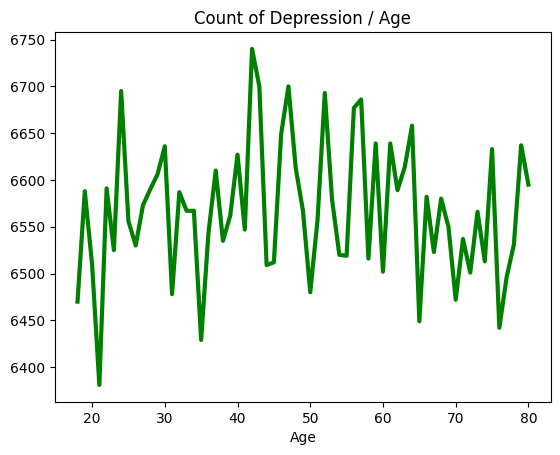

In [8]:
(df_depression
 .groupby ('Age')
 ['Name']
 .count()
 .plot.line (lw=3,
          c="green"
          , title = "Count of Depression / Age")
);

In [9]:
# (5) Calculating of the peak values:

Peak_age=df_depression.groupby ('Age')['Name'].count().sort_values (ascending = False).head (1).idxmax()
print ("The largest number of individuals with depression in our dataset at the age of:",Peak_age,".")
#Peak_age2 = df_depression.groupby ('Age')['Name'].count().sort_values ().tail(1)
#Peak_age2

Peak_age_min=df_depression.groupby ('Age')['Name'].count().sort_values (ascending = True).head (1).idxmax()
print ("The lowest count of individuals diagnosed with depression in our dataset at the age of:",Peak_age_min,".")

The largest number of individuals with depression in our dataset at the age of: 42 .
The lowest count of individuals diagnosed with depression in our dataset at the age of: 21 .


In [10]:
# Count of Depression VS Age bins:

Age_bins = pd.cut(
    df_depression.Age,
    bins=[0,40,65,99],
    labels=["Young adult\n18-40","Middle age\n41-65", "Old adult\n>65"] # From Wikipedia
)

The group with the highest number of people experiencing depression in our dataset is /Middle age 41-65/



<ipython-input-11-c904ebe4ea5a>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby (Age_bins)


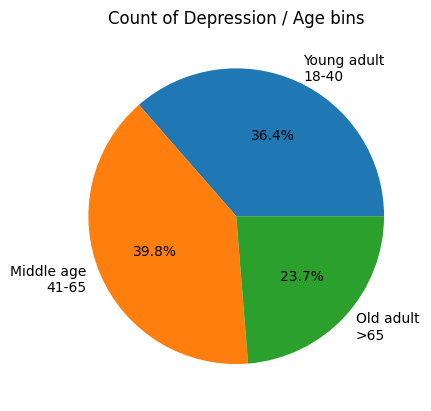

In [11]:
(df_depression
 .groupby (Age_bins)
 ['Name']
 .count()
 .plot.pie (autopct = '%1.1f%%', ylabel='', title = "Count of Depression / Age bins")
)
text1 = "The group with the highest number of people experiencing depression in our dataset is /Middle age 41-65/."
sentences1 = text1.split('.')
for sentence1 in sentences1:
    print(sentence1)


(6)**Depression and Marital Status**

Hypothesis - lonely people are most susceptible to depression.

Marital_Status
Married     58.0
Single      17.0
Widowed     17.0
Divorced     8.0
Name: Name, dtype: float64

3) Loneliness and lack of familian and social support are cited as contributing factors to depression;
When grouping our dataset only by marital status, revealed that the largest group was married individuals, which contradicts the aforementioned;


The total number of people: 155232

Marital_Status  Number_of_Children
Single          0                     46.0
Married         0                     37.0
Widowed         0                     11.0
Divorced        0                      5.0
Name: Name, dtype: float64

4) Depressed patients who are single in our dataset are all childless;
 Conversely, those with other marital statuses may have varying numbers of children, from 0 to 4;
When the sample is limited exclusively to childless individuals, the proportion of patients with depression among singles reaches maximum value;
Male/Female;


The total number of people: 50048

Mari

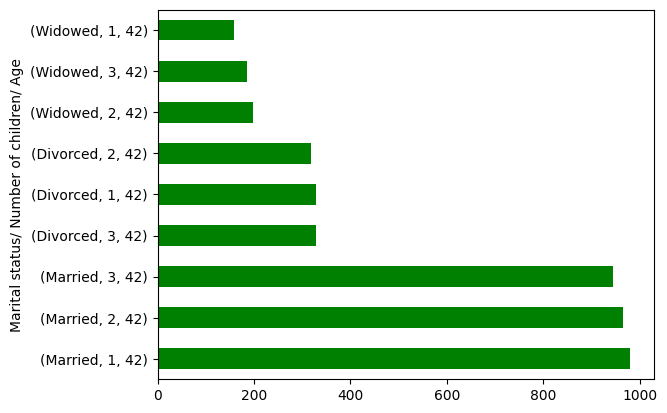

In [48]:
#total_number1=df_depression.sum (axis=0)
#print('The total number of people:',total_number1)
#print()

df_marital_status=(df_depression
 .groupby ('Marital_Status')
 ['Name']
 .count()
 .sort_values(ascending=False)
)
print (round(df_marital_status/413768*100))
print()

text3 = "3) Loneliness and lack of familian and social support are cited as contributing factors to depression;.When grouping our dataset only by marital status, revealed that the largest group was married individuals, which contradicts the aforementioned;."
sentences3 = text3.split('.')
for sentence3 in sentences3:
    print(sentence3)


print()

# boolean mask "Number_of_Children" = 0:
df_have_no_children = df_depression.loc[df_depression.Number_of_Children == 0]

df_martial_st_children=(df_have_no_children
 .groupby (['Marital_Status','Number_of_Children'])
 ['Name']
 .count()
 .sort_values(ascending = False)
 )

total_number2=df_martial_st_children.sum (axis=0)
print('The total number of people:',total_number2)
print()

print (round(df_martial_st_children/total_number2*100))
print()

text4 = "4) Depressed patients who are single in our dataset are all childless;. Conversely, those with other marital statuses may have varying numbers of children, from 0 to 4;.When the sample is limited exclusively to childless individuals, the proportion of patients with depression among singles reaches maximum value;.Male/Female;."
sentences4 = text4.split('.')
for sentence4 in sentences4:
    print(sentence4)
print()

df_martial_st_children_age=(df_have_no_children
 .groupby (['Marital_Status','Number_of_Children','Age'])
 ['Name']
 .count()
 .sort_values(ascending = False)
 .head(10)
 )
total_number2a=df_martial_st_children_age.sum (axis=0)
print('The total number of people:',total_number2a)
print()

print (round(df_martial_st_children_age/total_number2a*100))
print()

age_test=int(input("Please enter your age: "))
# boolean mask "Number_of_Children" = 1-3:
df_have_children = df_depression.loc[(df_depression.Number_of_Children >= 1) & (df_depression.Number_of_Children <=3)&(df_depression.Age==age_test)]

df_martial_st_have_children_age=(df_have_children
 .groupby (['Marital_Status','Number_of_Children','Age'])
 ['Name']
 .count()
 .sort_values(ascending = False)
 .head(20)
 )
total_number2b=df_martial_st_have_children_age.sum (axis=0)
print('The total number of people:',total_number2b)
print()

print (round(df_martial_st_have_children_age/total_number2b*100))
print()


ddd=df_martial_st_have_children_age.plot.barh(color='green', ylabel="Marital status/ Number of children/ Age")
print(ddd)

(7)**Depression and Education_Level**

Individuals with primary education are five times more likely to experience moderate to severe depression compared to university graduates. The unemployed are twelve times more likely to suffer from these symptoms than the employed.

In [13]:
 #(Associate degree - level of academic qualification above a high school diploma and below a bacelor's degree.)

df_education_level = (df_depression
 .groupby ('Education_Level')
 ['Name']
 .count()
 .sort_values(ascending=False)
 #.plot.barh(ylabel='', title = "Count of Depression / Education Level")
);
print (round(df_education_level/413768*100));
print ()

text5 = "5) Another cause of depression is a very high or extremely low financial status;. Undoubtedly, the level of education influences the level of material well-being;. An initial grouping of people suffering from depression by education level showed that the largest number of patients have a bachelor's degree;. This does not mean anything, only that the largest number of patients in our dataset have a bachelor's degree;."
sentences5 = text5.split('.')
for sentence5 in sentences5:
    print(sentence5);


Income_bins = pd.cut(
    df_depression.Income,
    bins=[0,58000,100000,300000],
    labels=["Income\n0-58K","Income\n59-100K", "Income\n>101K"]
);


df_education_income = (df_depression
 .groupby (['Education_Level', Income_bins])
 ['Name']
 .count()
 .sort_values(ascending=False)
 .head(10)
 #.plot.barh(ylabel='', title = "Count of Depression / Education Level")
);

total_number3=df_education_income.sum (axis=0)
print('The total number of people:',total_number3)
print()

print (round(df_education_income/total_number3*100));
print ();

text6 = "6) When we grouped individuals by education level and income, we found that those with only a secondary education and low incomes were most likely to experience depression;."
sentences6 = text6.split('.')
for sentence6 in sentences6:
    print(sentence6);


df_education_income_ms = (df_have_no_children
 .groupby (['Education_Level', Income_bins,'Marital_Status'])
 ['Name']
 .count()
 .sort_values(ascending=False)
 .head(10)
 );

total_number4=df_education_income_ms.sum (axis=0)
print('The total number of people:',total_number4)
print()

print (round(df_education_income_ms/total_number4*100));
print ()
print ("7) Individuals with a high school education, low income, and single status are most likely to experience depression.");
print ()

Education_Level
Bachelor's Degree    30.0
High School          29.0
Associate Degree     19.0
Master's Degree      18.0
PhD                   4.0
Name: Name, dtype: float64

5) Another cause of depression is a very high or extremely low financial status;
 Undoubtedly, the level of education influences the level of material well-being;
 An initial grouping of people suffering from depression by education level showed that the largest number of patients have a bachelor's degree;
 This does not mean anything, only that the largest number of patients in our dataset have a bachelor's degree;

The total number of people: 407346

Education_Level    Income         
High School        Income\n0-58K      29.0
Associate Degree   Income\n0-58K      17.0
Bachelor's Degree  Income\n59-100K    15.0
                   Income\n0-58K      12.0
Master's Degree    Income\n>101K       8.0
                   Income\n0-58K       7.0
                   Income\n59-100K     3.0
Associate Degree   Income\n59-100

<ipython-input-13-a2cf408aef97>:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby (['Education_Level', Income_bins])
<ipython-input-13-a2cf408aef97>:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby (['Education_Level', Income_bins,'Marital_Status'])


In [14]:
#  Calculating the peak value (5):

Peak_education_level=(df_depression.groupby ('Education_Level')['Name'].count().sort_values(ascending = False).idxmax())
Peak_education_level

"Bachelor's Degree"

Converting categorical values to numerical values and then group them.



<Axes: title={'center': 'Chronic Medical Conditions'}>

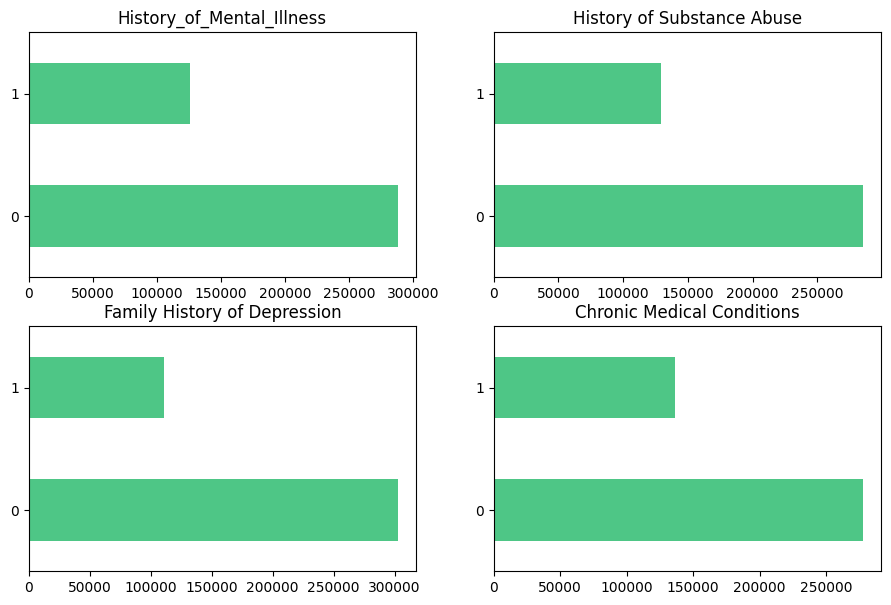

In [15]:
# Depression VS Health:


print ("Converting categorical values to numerical values and then group them.")
df_depression['Mental_Illness_num'] = df_depression['History_of_Mental_Illness'].replace({'Yes': 1, 'No': 0})
df_depression['Substance_Abuse_num'] = df_depression['History_of_Substance_Abuse'].replace({'Yes': 1, 'No': 0})
df_depression['History_of_Depression_num'] = df_depression['Family_History_of_Depression'].replace({'Yes': 1, 'No': 0})
df_depression['Chronic_Med_Conditions_num'] = df_depression['Chronic_Medical_Conditions'].replace({'Yes': 1, 'No': 0})
print ()


fig,axes = plt.subplots (nrows = 2,ncols = 2,figsize = (11,7))
df_depression.groupby ('Mental_Illness_num')['Name'].count().plot.barh(title="History_of_Mental_Illness",color = '#4ec686', ylabel="", ax=axes [0][0])
df_depression.groupby ('Substance_Abuse_num')['Name'].count().plot.barh(title="History of Substance Abuse",color = '#4ec686',ylabel="", ax=axes [0][1]) #Drugs
df_depression.groupby ('History_of_Depression_num')['Name'].count().plot.barh(title="Family History of Depression",color = '#4ec686',ylabel="",ax=axes [1][0])
df_depression.groupby ('Chronic_Med_Conditions_num')['Name'].count().plot.barh(title="Chronic Medical Conditions",color = '#4ec686',ylabel="", ax=axes [1][1])



Converting categorical values to numerical values and then group them.



<Axes: title={'center': 'Physical Activity Level'}>

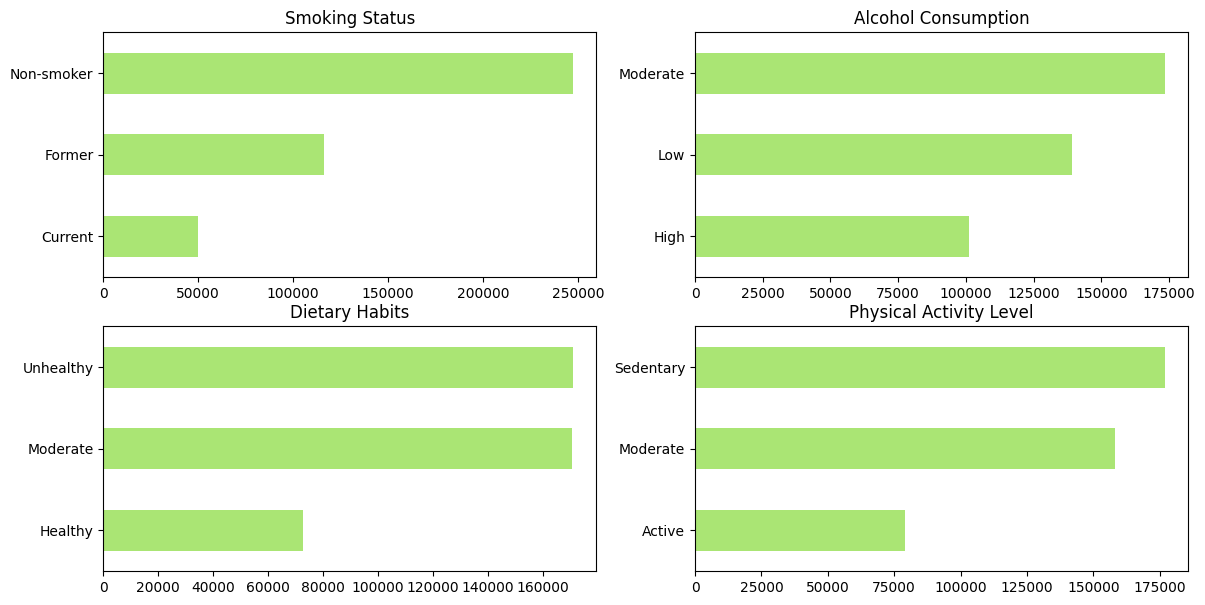

In [16]:
# Depression VS Lifestyle:


print ("Converting categorical values to numerical values and then group them.")
df_depression['Smoking_Status_num'] = df_depression['Smoking_Status'].replace({'Current': 2,'Former': 1, 'Non-smoker': 0})
df_depression['Alcohol_Consumption_num'] = df_depression['Alcohol_Consumption'].replace({'High': 2, 'Moderate': 1, 'Low': 0})
df_depression['Dietary_Habits_num'] = df_depression['Dietary_Habits'].replace({'Unhealthy': 2, 'Moderate': 1, 'Healthy': 0})
df_depression['Physical_Activity_Level_num'] = df_depression['Physical_Activity_Level'].replace({'Sedentary': 2, 'Moderate': 1, 'Active': 0})
print ()

fig,axes = plt.subplots (nrows = 2,ncols = 2,figsize = (14,7))
df_depression.groupby ('Smoking_Status')['Name'].count().plot.barh(title="Smoking Status",color = '#aae574',ylabel="", ax=axes [0][0])
df_depression.groupby ('Alcohol_Consumption')['Name'].count().plot.barh(title="Alcohol Consumption",color = '#aae574',ylabel="", ax=axes [0][1])
df_depression.groupby ('Dietary_Habits')['Name'].count().plot.barh(title="Dietary Habits",color = '#aae574',ylabel="",ax=axes [1][0])
df_depression.groupby ('Physical_Activity_Level')['Name'].count().plot.barh(title="Physical Activity Level",color = '#aae574',ylabel="", ax=axes [1][1])


In [17]:
#(8)
df_depression_splitted = df_depression[['Name', 'Surname']] = df_depression['Name'].str.split(' ',n=1, expand=True)

In [18]:
df_depression.sample(5)

,Name,Age,Marital_Status,Education_Level,Number_of_Children,Smoking_Status,Physical_Activity_Level,Employment_Status,Income,Alcohol_Consumption,...,Chronic_Medical_Conditions,Mental_Illness_num,Substance_Abuse_num,History_of_Depression_num,Chronic_Med_Conditions_num,Smoking_Status_num,Alcohol_Consumption_num,Dietary_Habits_num,Physical_Activity_Level_num,Surname
224673,Jennifer,23,Single,High School,0,Former,Sedentary,Employed,42024.86,Moderate,...,No,0,0,0,0,1,1,2,2,Robbins
72623,Christina,39,Married,High School,4,Former,Moderate,Employed,40241.41,Low,...,No,0,1,1,0,1,0,2,1,Vance
170029,Teresa,39,Married,Master's Degree,4,Non-smoker,Moderate,Employed,147923.17,High,...,No,0,1,0,0,0,2,0,1,Walter
65195,Jenna,62,Widowed,Associate Degree,1,Non-smoker,Sedentary,Employed,44332.66,Moderate,...,No,0,0,1,0,0,1,1,2,Moore
96398,Rebecca,28,Single,Associate Degree,0,Non-smoker,Active,Employed,61705.78,Moderate,...,No,0,0,0,0,0,1,2,0,Mason


In [19]:
# Dataset 'df_depression':
df_depression.loc [:,['Name','Surname','Age']].head(7)

,Name,Surname,Age
0,Christine,Barker,31
1,Jacqueline,Lewis,55
2,Shannon,Church,78
3,Charles,Jordan,58
4,Michael,Rich,18
5,Kathy,Hill,20
6,Crystal,Delgado,60


In [20]:
# Count of distinct names in the dataset 'df_depression':
df_depression.Name.nunique()

695

In [21]:
# Count of distinct last names in the dataset 'df_depression':
df_depression.Surname.nunique()

12125

In [22]:
#(9) Сhecking the percentage ratio of men and women suffering from depression using the 'df_names_by_nationality' dataset:

df_names_by_nationality=pd.read_csv ('names-by-nationality.csv')
#df_names_by_nationality.head (10)
df_names_by_nationality.tail (10)
#df_names_by_nationality.sample (10)

,name,sex,nationality
4685,Winola,Female,American
4686,Winter,Neutral,American
4687,Winterlynn,Female,American
4688,Wood,Male,American
4689,Woody,Male,American
4690,Worth,Male,American
4691,Wrigley,Neutral,American
4692,X-iomania,Female,American
4693,Xadrian,Male,American
4694,Xakery,Male,American


In [23]:
df_names_by_nationality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4695 entries, 0 to 4694
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         4695 non-null   object
 1   sex          4695 non-null   object
 2   nationality  4695 non-null   object
dtypes: object(3)
memory usage: 110.2+ KB


In [24]:
df_names_by_nationality.describe() # 3 genders of names: male, female and gender-neutral

,name,sex,nationality
count,4695,4695,4695
unique,4695,3,7
top,Aarav,Female,American
freq,1,2573,1782


In [25]:
# Count of distinct nationalities:
df_names_by_nationality.nationality.nunique()

7

In [26]:
# 7 nationalities: Indian, Russian, Japanese, African, German, French, American
df_names_by_nationality.nationality.unique()

array(['Indian', 'Russian', 'Japanese', 'African', 'German', 'French',
       'American'], dtype=object)

In [27]:
# Which nationality has the largest number of names in the dataset - American:


df_names_by_nationality.groupby('nationality')['name'].count().sort_values(ascending = False)


,name
nationality,
American,1782
Japanese,757
French,584
Indian,576
African,520
German,334
Russian,142


In [28]:
# Which :
df_names_by_nationality.groupby('sex')['name'].count().sort_values(ascending = False)

,name
sex,
Female,2573
Male,1356
Neutral,766


In [29]:
#Left Join for 'df_depression' and 'df_names_by_nationality':

df_depression_merged=df_depression.merge(df_names_by_nationality, left_on="Name", right_on="name", how="left")
df_depression_merged_sv=df_depression_merged.loc [:,['Name','Surname','Age','name','sex','nationality']]
df_depression_merged_sv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413768 entries, 0 to 413767
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Name         413768 non-null  object
 1   Surname      413768 non-null  object
 2   Age          413768 non-null  int64 
 3   name         41754 non-null   object
 4   sex          41754 non-null   object
 5   nationality  41754 non-null   object
dtypes: int64(1), object(5)
memory usage: 18.9+ MB


In [30]:
main_table = df_depression_merged_sv.Name.notnull().sum() # Number of names in the main table
additional_table = df_depression_merged_sv.name.notnull().sum() # Number of names in the additional table
name_matches = round(additional_table/main_table*100) # Number of matches in percentage
print ("When we merged the two datasets 'df_depression' and 'df_names_by_nationality' only",name_matches,"% of the records matched.")

When we merged the two datasets 'df_depression' and 'df_names_by_nationality' only 10 % of the records matched.


              Name  Surname  Age        name     sex nationality
1       Jacqueline    Lewis   55  Jacqueline  Female      French
27          Yvonne    Evans   33      Yvonne  Female      French
65           Sonya   Fuller   66       Sonya  Female     Russian
75         Valerie   Mosley   32     Valerie  Female      French
92           Henry   Oliver   76       Henry    Male      German
...            ...      ...  ...         ...     ...         ...
413719       Shawn   Gaines   61       Shawn    Male    American
413727      Brandy    Beard   67      Brandy  Female    American
413735     Darlene   Howard   47     Darlene  Female    American
413741       Karla    Young   21       Karla  Female      German
413756        Karl  Elliott   72        Karl    Male      German

[41754 rows x 6 columns]


<Axes: >

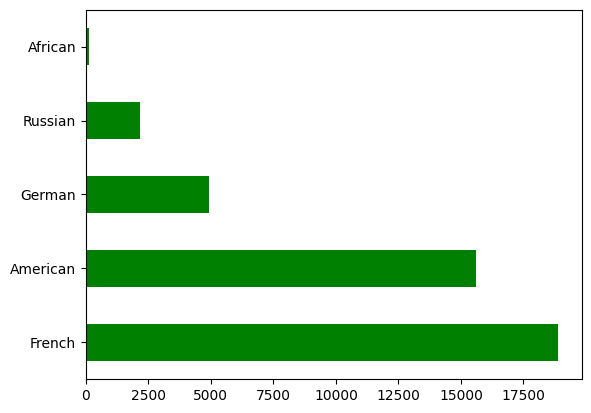

In [31]:
# Columns without null values:

df_depression_merged_sv_nonull = df_depression_merged_sv[df_depression_merged_sv.notnull().all(axis=1)==True]
print (df_depression_merged_sv_nonull)

# Percentage of nationalities in the dataset:

(df_depression_merged_sv_nonull
.groupby('nationality')
['Name']
.count()
.sort_values(ascending=False)
.head(10)
.plot.barh(ylabel='',color = 'green'))


(10)**Depression and Gender**

Women are about 50% more likely to experience depression than men.

8) Both men and women can experience mental health issues, but depression is more common among women;
 In fact, nearly twice as many women (8,5%) suffer from depression compared to men (4,7%);
The percentage of women in our dataset significantly exceeds the percentage of men;



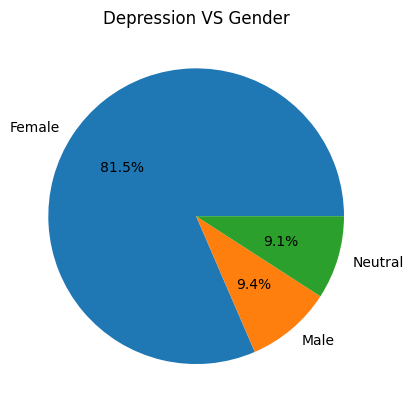

In [32]:
df_depression_merged_sv_nonull.groupby('sex')['Name'].count().plot.pie(autopct = '%1.1f%%', ylabel='',title = "Depression VS Gender");

text8 = "8) Both men and women can experience mental health issues, but depression is more common among women;. In fact, nearly twice as many women (8,5%) suffer from depression compared to men (4,7%);.The percentage of women in our dataset significantly exceeds the percentage of men;."
sentences8 = text8.split('.')
for sentence8 in sentences8:
    print(sentence8);

<ipython-input-33-170b6eb3720b>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df_female.groupby(Age_bins)['Name'].count().plot.barh(title = "Count of female respondents", color='red')
<ipython-input-33-170b6eb3720b>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_male.groupby(Age_bins)['Name'].count().plot.barh(title = "Count of male(green) / female(red) respondents",color='green',ylabel='', ax=ax)


<Axes: title={'center': 'Count of male(green) / female(red) respondents'}>

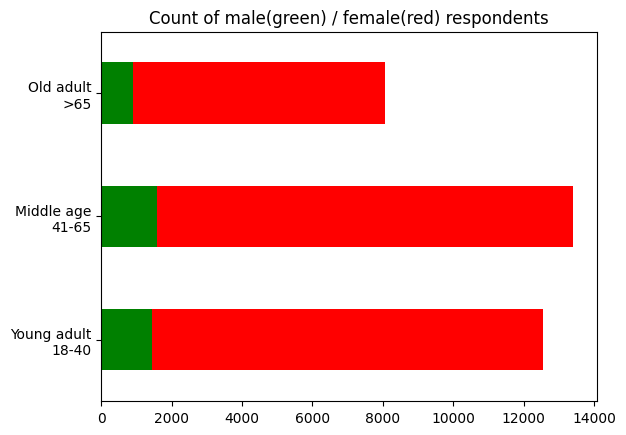

In [33]:
df_female = df_depression_merged_sv_nonull.loc[df_depression_merged_sv_nonull.sex=='Female']
ax = df_female.groupby(Age_bins)['Name'].count().plot.barh(title = "Count of female respondents", color='red')
#plt.show();

df_male = df_depression_merged_sv_nonull.loc[df_depression_merged_sv_nonull.sex=='Male']
df_male.groupby(Age_bins)['Name'].count().plot.barh(title = "Count of male(green) / female(red) respondents",color='green',ylabel='', ax=ax)
#plt.show();

<Axes: title={'center': 'Count of male(green) / female(red) respondents'}, xlabel='Age'>

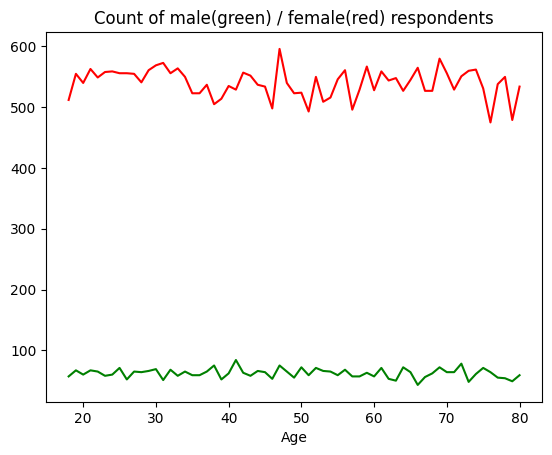

In [34]:
df_female = df_depression_merged_sv_nonull.loc[df_depression_merged_sv_nonull.sex=='Female']
ax = df_female.groupby('Age')['Name'].count().plot.line (title = "Count of female respondents", color='red')
#plt.show();

df_male = df_depression_merged_sv_nonull.loc[df_depression_merged_sv_nonull.sex=='Male']
df_male.groupby('Age')['Name'].count().plot.line(title = "Count of male(green) / female(red) respondents",color='green',ylabel='', ax=ax)
#plt.show();

<Axes: title={'center': 'Count of female with good (red)/bad (blue) habbits (smoking, alcohol, junk food)'}, xlabel='Age'>

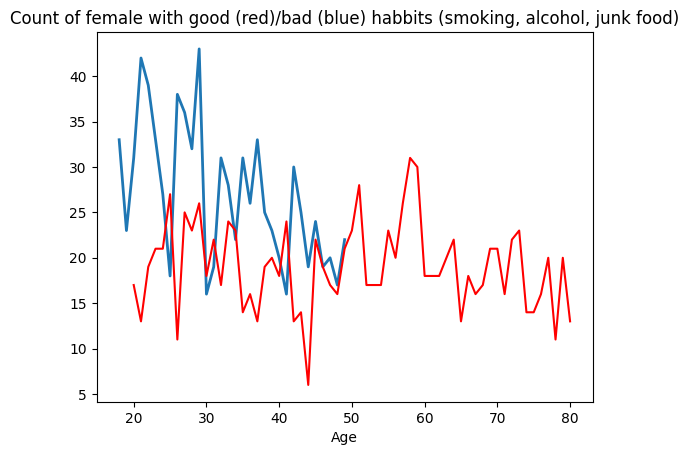

In [35]:
#Boolean mask:
df_bad_lifestyle_f = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Female') & (df_depression.Smoking_Status == 'Current') & (df_depression.Alcohol_Consumption == 'High')&(df_depression.Dietary_Habits=='Unhealthy')]
ax = df_bad_lifestyle_f.groupby('Age')['Name'].count().plot.line (lw=2, title = "Count of female with good (red)/bad (blue) habbits (smoking, alcohol, junk food)")

df_good_lifestyle_f = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Female') & (df_depression.Smoking_Status == 'Non-smoker') & (df_depression.Alcohol_Consumption == 'Low')&(df_depression.Dietary_Habits=='Healthy')]
df_good_lifestyle_f.groupby('Age')['Name'].count().plot.line (color = 'red', ax=ax)




<Axes: title={'center': 'Count of male with good (red)/bad (blue) habbits (smoking, alcohol, junk food)'}, xlabel='Age'>

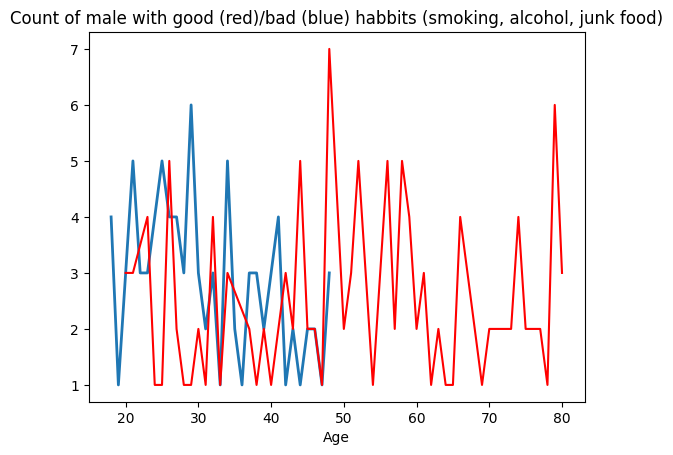

In [36]:
#Boolean mask:
df_bad_lifestyle_m = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Male') & (df_depression.Smoking_Status == 'Current') & (df_depression.Alcohol_Consumption == 'High')&(df_depression.Dietary_Habits=='Unhealthy')]
ax = df_bad_lifestyle_m.groupby('Age')['Name'].count().plot.line (lw=2, title = "Count of male with good (red)/bad (blue) habbits (smoking, alcohol, junk food)")

df_good_lifestyle_m = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Male') & (df_depression.Smoking_Status == 'Non-smoker') & (df_depression.Alcohol_Consumption == 'Low')&(df_depression.Dietary_Habits=='Healthy')]
df_good_lifestyle_m.groupby('Age')['Name'].count().plot.line (color = 'red', ax=ax)




<Axes: title={'center': 'Count of female with good (red)/bad (blue) Activity Level'}, xlabel='Age'>

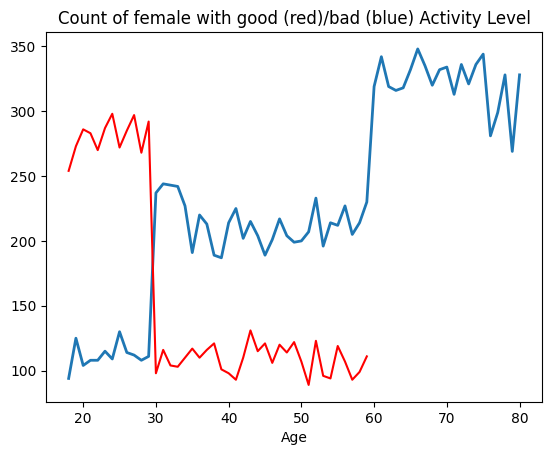

In [37]:
#Boolean mask:
df_bad_activity_f = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Female') & (df_depression.Physical_Activity_Level == 'Sedentary') ]
ax = df_bad_activity_f.groupby('Age')['Name'].count().plot.line (lw=2, title = "Count of female with good (red)/bad (blue) Activity Level")

df_good_activity_f = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Female') & (df_depression.Physical_Activity_Level == 'Active')]
df_good_activity_f.groupby('Age')['Name'].count().plot.line (color = 'red', ax=ax)



<Axes: title={'center': 'Count of male with good (red)/bad (blue) Activity Level'}, xlabel='Age'>

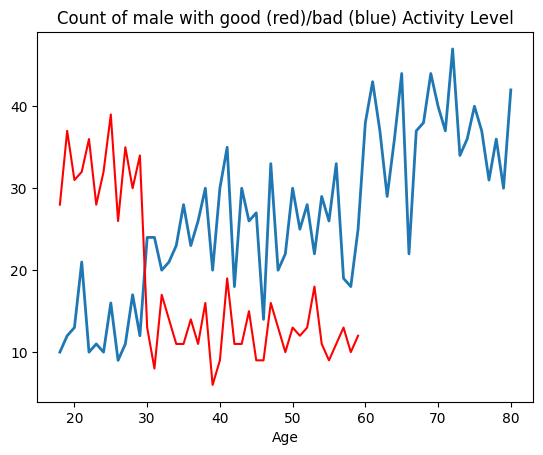

In [38]:
#Boolean mask:
df_bad_activity_m = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Male') & (df_depression.Physical_Activity_Level == 'Sedentary') ]
ax = df_bad_activity_m.groupby('Age')['Name'].count().plot.line (lw=2, title = "Count of male with good (red)/bad (blue) Activity Level")

df_good_activity_m = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Male') & (df_depression.Physical_Activity_Level == 'Active')]
df_good_activity_m.groupby('Age')['Name'].count().plot.line (color = 'red', ax=ax)



<Axes: title={'center': 'Count of female (blue)/male (red) with bad health history'}, xlabel='Age'>

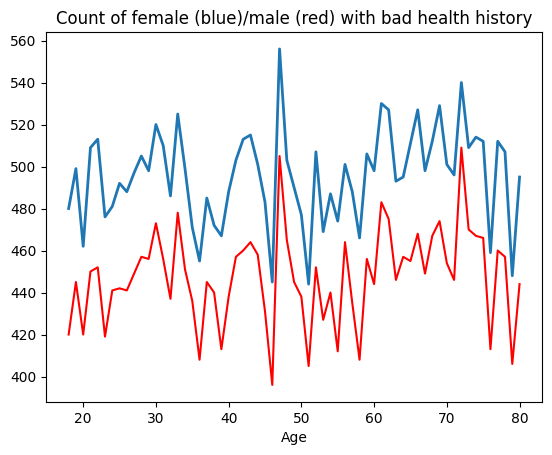

In [47]:
#Boolean mask:
df_bad_health_f = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Female') & (df_depression.History_of_Mental_Illness == 'Yes') | (df_depression.History_of_Substance_Abuse == 'Yes')|(df_depression.Family_History_of_Depression =='Yes')|(df_depression.Chronic_Medical_Conditions =='Yes')]
ax = df_bad_health_f.groupby('Age')['Name'].count().plot.line (lw=2, title = "Count of female (blue)/male (red) with bad health history")

df_bad_health_m = df_depression_merged_sv_nonull.loc[(df_depression_merged_sv_nonull.sex=='Male') & (df_depression.History_of_Mental_Illness == 'Yes') | (df_depression.History_of_Substance_Abuse == 'Yes')|(df_depression.Family_History_of_Depression =='Yes')|(df_depression.Chronic_Medical_Conditions =='Yes')]
df_bad_health_m.groupby('Age')['Name'].count().plot.line (color = 'red', ax=ax)





**Conclusions:**

Depression can start at any age, even in childhood, but most often starts during adolescence, after 20 or 30 years old.

Lack of close relationships and social support increases the risk of depression.

Low income, unemployment, and social inequality can increase the risk of developing depression.

Women are more likely to experience depression than men.